In [ ]:
!pip install pyarrow openpyxl imbalanced-learn --quiet

In [ ]:
"""
============================================================================
ADIM 1 — ÖN İŞLEME (Churn Modelleme / A Kolu)
Kozmetik E-Ticaret Churn Projesi
============================================================================
Hedef: Sızıntısız, modelleme-hazır müşteri-düzeyi veri seti üretmek.
Kritik kurallar:
  - recency_gun ve son_siparis MODELE GİRMEZ (tautoloji/sızıntı).
  - Imputation parametreleri SADECE train'den öğrenilir (test'e sızma yok).
  - SMOTE bu adımda YOK — Adım 3'te ve yalnızca train'e uygulanacak.
Literatür: Dengesiz veri ön işleme mantığı (Bitirme I, böl. 2.3.2).
============================================================================
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

DOSYA = "/content/kozmetik_surdurulebilir_churn_veri.xlsx"
RASTGELE = 42

# ---------------------------------------------------------------------------
# 0) Veriyi oku
# ---------------------------------------------------------------------------
df = pd.read_excel(DOSYA, sheet_name="Musteri_Tablosu")
print(f"Ham veri: {df.shape[0]} müşteri, {df.shape[1]} sütun")
print(f"Churn oranı: {df['churn'].mean():.4f}  "
      f"({df['churn'].sum()} churn / {len(df)} toplam)\n")

# ---------------------------------------------------------------------------
# 1) SIZINTI ve kimlik sütunlarını çıkar
# ---------------------------------------------------------------------------
# - recency_gun, son_siparis : churn doğrudan bunlardan tanımlı -> TAUTOLOJİ
# - ilk_siparis, uyelik_baslangic : ham tarih; bilgi musteri_omru_gun'de mevcut
# - musteri_id : kimlik
# - yesil_segment, yesil_musteri : ort_yesil_oran'dan deterministik türetilmiş
#       (EDA'da kullanılacak; modelde çoklu-bağlantı yaratmamak için çıkıyor)
SIZINTI = ["recency_gun", "son_siparis"]
KIMLIK_TARIH = ["musteri_id", "ilk_siparis", "uyelik_baslangic"]
TURETILMIS = ["yesil_segment", "yesil_musteri"]

HEDEF = "churn"
cikar = SIZINTI + KIMLIK_TARIH + TURETILMIS + [HEDEF]

X = df.drop(columns=cikar)
y = df[HEDEF].astype(int)

print("Modelden çıkarılan sütunlar:")
print(f"  Sızıntı       : {SIZINTI}")
print(f"  Kimlik/tarih  : {KIMLIK_TARIH}")
print(f"  Türetilmiş    : {TURETILMIS}")
print(f"\nModele giren aday özellikler ({X.shape[1]}): {list(X.columns)}\n")

# ---------------------------------------------------------------------------
# 2) TRAIN / TEST AYRIMI  (imputation'dan ÖNCE -> sızıntısız)
#    stratify=y : %16'lık churn oranı her iki sette korunur
# ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RASTGELE, stratify=y
)
print(f"Train: {X_train.shape[0]} satır (churn={y_train.mean():.3f}) | "
      f"Test: {X_test.shape[0]} satır (churn={y_test.mean():.3f})\n")

# ---------------------------------------------------------------------------
# 3) EKSİK VERİ — parametreler train'den, ikisine de uygulanır
# ---------------------------------------------------------------------------
sayisal_eksik = ["yas", "ort_puan"]   # medyan ile
kategorik_eksik = ["sehir"]           # "Bilinmiyor" ile

# 3a) eksiklik gösterge (flag) sütunları — eksikliğin kendisi sinyal olabilir
for kol in sayisal_eksik:
    bayrak = f"{kol}_eksikti"
    X_train[bayrak] = X_train[kol].isna().astype(int)
    X_test[bayrak]  = X_test[kol].isna().astype(int)

# 3b) sayısal: train medyanı
for kol in sayisal_eksik:
    med = X_train[kol].median()
    X_train[kol] = X_train[kol].fillna(med)
    X_test[kol]  = X_test[kol].fillna(med)
    print(f"  {kol:10}: train medyanı {med:.2f} ile dolduruldu")

# 3c) kategorik: 'Bilinmiyor'
for kol in kategorik_eksik:
    X_train[kol] = X_train[kol].fillna("Bilinmiyor")
    X_test[kol]  = X_test[kol].fillna("Bilinmiyor")
    print(f"  {kol:10}: 'Bilinmiyor' kategorisi ile dolduruldu")

# güvenlik kontrolü
assert X_train.isna().sum().sum() == 0, "train'de hâlâ eksik var!"
assert X_test.isna().sum().sum() == 0, "test'te hâlâ eksik var!"
print("  -> Eksik değer kalmadı.\n")

# ---------------------------------------------------------------------------
# 4) KATEGORİK KODLAMA
#    cinsiyet (ikili) -> 0/1 ; sehir -> one-hot
#    Not: CatBoost kullanırsan bu adımı atlayıp ham kategorikleri verebilirsin.
# ---------------------------------------------------------------------------
X_train["cinsiyet"] = (X_train["cinsiyet"] == "Kadın").astype(int)  # Kadın=1
X_test["cinsiyet"]  = (X_test["cinsiyet"] == "Kadın").astype(int)

# one-hot: train kategorilerine sabitle, test'i aynı sütunlara hizala
X_train = pd.get_dummies(X_train, columns=["sehir"], prefix="sehir")
X_test  = pd.get_dummies(X_test,  columns=["sehir"], prefix="sehir")
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)  # hizalama

# tüm boolean sütunları int'e çevir (model uyumu)
X_train = X_train.astype({c: int for c in X_train.select_dtypes("bool").columns})
X_test  = X_test.astype({c: int for c in X_test.select_dtypes("bool").columns})

print(f"Son özellik sayısı: {X_train.shape[1]}")
print(f"Özellikler: {list(X_train.columns)}\n")

# ---------------------------------------------------------------------------
# 5) Diske kaydet (sonraki adımlar buradan okuyacak)
# ---------------------------------------------------------------------------
X_train.to_parquet("X_train.parquet"); X_test.to_parquet("X_test.parquet")
y_train.to_frame("churn").to_parquet("y_train.parquet")
y_test.to_frame("churn").to_parquet("y_test.parquet")
print("Kaydedildi: X_train / X_test / y_train / y_test (.parquet)")
print("ADIM 1 TAMAM.")

Ham veri: 2500 müşteri, 24 sütun
Churn oranı: 0.1624  (406 churn / 2500 toplam)

Modelden çıkarılan sütunlar:
  Sızıntı       : ['recency_gun', 'son_siparis']
  Kimlik/tarih  : ['musteri_id', 'ilk_siparis', 'uyelik_baslangic']
  Türetilmiş    : ['yesil_segment', 'yesil_musteri']

Modele giren aday özellikler (16): ['yas', 'cinsiyet', 'sehir', 'siparis_sayisi', 'musteri_omru_gun', 'ort_siparis_araligi', 'siparis_sikligi_ay', 'toplam_harcama', 'ort_sepet', 'ort_yesil_oran', 'toplam_yesil_urun', 'sikayet_top', 'sikayet_orani', 'iade_top', 'iade_orani', 'ort_puan']

Train: 2000 satır (churn=0.163) | Test: 500 satır (churn=0.162)

  yas       : train medyanı 34.00 ile dolduruldu
  ort_puan  : train medyanı 4.25 ile dolduruldu
  sehir     : 'Bilinmiyor' kategorisi ile dolduruldu
  -> Eksik değer kalmadı.

Son özellik sayısı: 26
Özellikler: ['yas', 'cinsiyet', 'siparis_sayisi', 'musteri_omru_gun', 'ort_siparis_araligi', 'siparis_sikligi_ay', 'toplam_harcama', 'ort_sepet', 'ort_yesil_oran', 't

1) YEŞİL MÜŞTERİ vs DİĞERLERİ — churn
  Yeşil değil (0): churn 0.2535  (n=990)
  Yeşil      (1) : churn 0.1026  (n=1510)
  Ki-kare p-değeri: 2.558e-23  -> ANLAMLI (p<0.05)


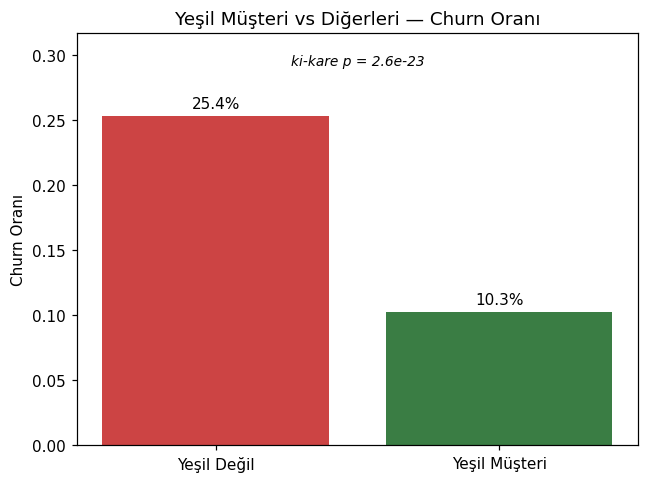


2) SEGMENT bazında churn (Truong 2016)
  İlgisiz       : churn 0.2535  (n=990)
  Pasif Yeşil   : churn 0.1463  (n=704)
  Aktif Yeşil   : churn 0.0645  (n=806)
  Ki-kare p-değeri: 1.798e-26  -> ANLAMLI (p<0.05)


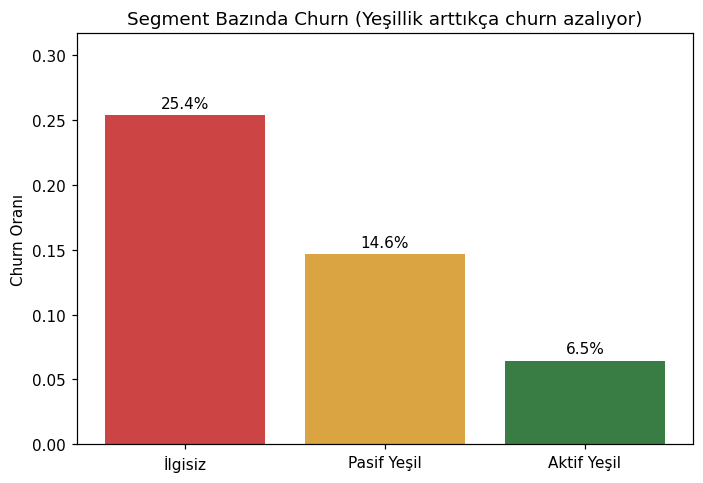


3) MEVSİMSELLİK — aylık sipariş hacmi
  2025-02: 385
  2025-03: 1407
  2025-04: 1925
  2025-05: 2118
  2025-06: 1580
  2025-07: 1381
  2025-08: 1450
  2025-09: 1774
  2025-10: 1820
  2025-11: 2746
  2025-12: 2070
  2026-01: 1073


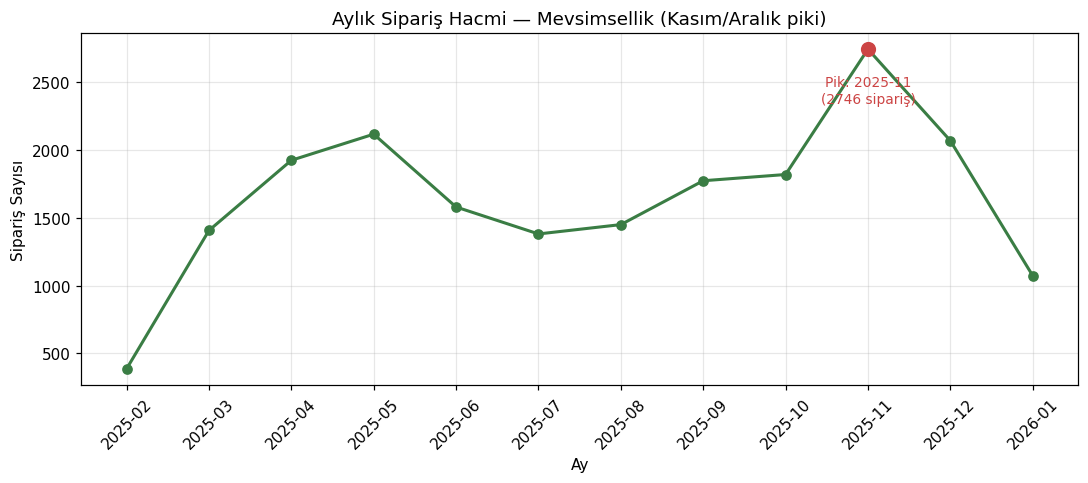


ADIM 2 TAMAM. Grafikler /content/grafikler/ altına kaydedildi.


In [ ]:
"""
============================================================================
ADIM 2 — KEŞİFÇİ ANALİZ (EDA) / Churn Modelleme (A Kolu)
============================================================================
Amaç: Modelleme öncesi ANA HİPOTEZİ kontrol etmek:
      "Yeşil (sürdürülebilir) ürün alan müşteriler daha düşük churn oranına sahiptir."
Üretilenler:
  (1) Yeşil müşteri vs diğerleri — churn karşılaştırması + ki-kare testi
  (2) Segment bazında churn (Truong 2016: Aktif/Pasif/İlgisiz) — doz-yanıt
  (3) Mevsimsellik — aylık sipariş hacmi (Islem_Tablosu)
Not: EDA HAM veriden yapılır (parquet'ten değil); çünkü betimsel analizdir ve
     yesil_musteri/yesil_segment/tarih sütunlarına ihtiyaç vardır.
============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import os

DOSYA = "/content/kozmetik_surdurulebilir_churn_veri.xlsx"   # Colab yolu
CIKTI = "/content/grafikler"
os.makedirs(CIKTI, exist_ok=True)
plt.rcParams["figure.dpi"] = 110

m  = pd.read_excel(DOSYA, sheet_name="Musteri_Tablosu")
it = pd.read_excel(DOSYA, sheet_name="Islem_Tablosu")

# ===========================================================================
# 1) YEŞİL MÜŞTERİ vs DİĞERLERİ — churn
# ===========================================================================
print("="*60); print("1) YEŞİL MÜŞTERİ vs DİĞERLERİ — churn"); print("="*60)
rate = m.groupby("yesil_musteri")["churn"].mean()
n0, n1 = (m.yesil_musteri == 0).sum(), (m.yesil_musteri == 1).sum()
print(f"  Yeşil değil (0): churn {rate[0]:.4f}  (n={n0})")
print(f"  Yeşil      (1) : churn {rate[1]:.4f}  (n={n1})")

tab = pd.crosstab(m["yesil_musteri"], m["churn"])
chi2, p, dof, _ = chi2_contingency(tab)
print(f"  Ki-kare p-değeri: {p:.4g}  -> "
      + ("ANLAMLI (p<0.05)" if p < 0.05 else "anlamsız"))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Yeşil Değil", "Yeşil Müşteri"], [rate[0], rate[1]],
              color=["#c44", "#3a7d44"])
ax.set_ylabel("Churn Oranı"); ax.set_title("Yeşil Müşteri vs Diğerleri — Churn Oranı")
ax.bar_label(bars, labels=[f"{rate[0]:.1%}", f"{rate[1]:.1%}"], padding=3)
ax.set_ylim(0, max(rate)*1.25)
ax.text(0.5, 0.95, f"ki-kare p = {p:.2g}", transform=ax.transAxes,
        ha="center", va="top", fontsize=9, style="italic")
plt.tight_layout(); plt.savefig(f"{CIKTI}/01_yesil_vs_churn.png"); plt.show()

# ===========================================================================
# 2) SEGMENT bazında churn (Truong 2016)
# ===========================================================================
print("\n" + "="*60); print("2) SEGMENT bazında churn (Truong 2016)"); print("="*60)
seg_order = ["İlgisiz", "Pasif Yeşil", "Aktif Yeşil"]
seg = m.groupby("yesil_segment")["churn"].agg(["mean", "count"]).reindex(seg_order)
for s, r in seg.iterrows():
    print(f"  {s:14}: churn {r['mean']:.4f}  (n={int(r['count'])})")
chi2b, pb, _, _ = chi2_contingency(pd.crosstab(m["yesil_segment"], m["churn"]))
print(f"  Ki-kare p-değeri: {pb:.4g}  -> "
      + ("ANLAMLI (p<0.05)" if pb < 0.05 else "anlamsız"))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = ["#c44", "#d9a441", "#3a7d44"]
bars = ax.bar(seg_order, seg["mean"].values, color=colors)
ax.set_ylabel("Churn Oranı")
ax.set_title("Segment Bazında Churn (Yeşillik arttıkça churn azalıyor)")
ax.bar_label(bars, labels=[f"{v:.1%}" for v in seg["mean"].values], padding=3)
ax.set_ylim(0, seg["mean"].max()*1.25)
plt.tight_layout(); plt.savefig(f"{CIKTI}/02_segment_churn.png"); plt.show()

# ===========================================================================
# 3) MEVSİMSELLİK — aylık sipariş hacmi
# ===========================================================================
print("\n" + "="*60); print("3) MEVSİMSELLİK — aylık sipariş hacmi"); print("="*60)
it["siparis_tarihi"] = pd.to_datetime(it["siparis_tarihi"])
it["ay"] = it["siparis_tarihi"].dt.to_period("M").astype(str)
aylik = it.groupby("ay").size()
for ay, n in aylik.items():
    print(f"  {ay}: {n}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(aylik.index, aylik.values, marker="o", color="#3a7d44", linewidth=2)
pik = aylik.idxmax()
ax.scatter([pik], [aylik.max()], color="#c44", zorder=5, s=80)
ax.annotate(f"Pik: {pik}\n({aylik.max()} sipariş)",
            xy=(pik, aylik.max()), xytext=(0, -35),
            textcoords="offset points", ha="center", color="#c44", fontsize=9)
ax.set_ylabel("Sipariş Sayısı"); ax.set_xlabel("Ay")
ax.set_title("Aylık Sipariş Hacmi — Mevsimsellik (Kasım/Aralık piki)")
plt.xticks(rotation=45); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{CIKTI}/03_mevsimsellik.png"); plt.show()

print("\nADIM 2 TAMAM. Grafikler /content/grafikler/ altına kaydedildi.")

Train: (2000, 26) | churn=0.163
Test : (500, 26) | churn=0.162  (test'e DOKUNULMAYACAK)

DENGELEME YÖNTEMLERİ KARŞILAŞTIRMASI (model: Random Forest)
        Yöntem  Precision   Recall       F1      AUC  train_n  train_churn%
    1-Baseline   0.671429 0.580247 0.622517 0.925499     2000         0.162
2-class_weight   0.682540 0.530864 0.597222 0.928681     2000         0.162
       3-SMOTE   0.620690 0.666667 0.642857 0.925381     3350         0.500
   4-SMOTE-ENN   0.622642 0.814815 0.705882 0.921241     2645         0.512

Tablo kaydedildi: /content/sonuclar/adim3_dengeleme_karsilastirma.csv

>> En yüksek F1: 4-SMOTE-ENN  (churn'de recall önceliğiyle birlikte değerlendir)


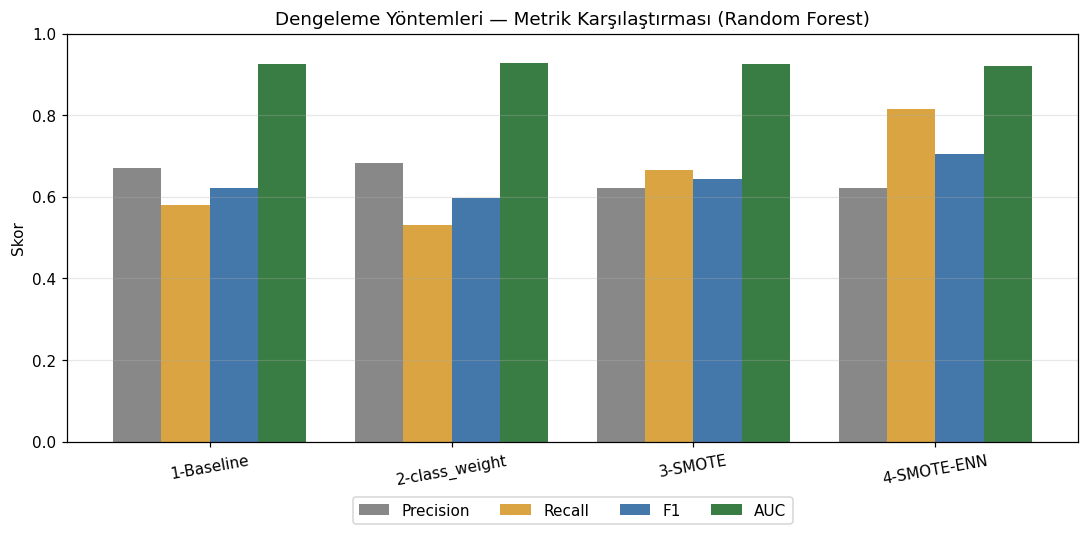


ADIM 3 TAMAM.


In [ ]:
"""
============================================================================
ADIM 3 — DENGESİZ VERİ YÖNETİMİ / Churn Modelleme (A Kolu)
============================================================================
Amaç: 4 dengeleme stratejisini SABİT model (Random Forest) üzerinde
      karşılaştırmak ve en iyisini Adım 4'e taşımak.
  1) Baseline (müdahale yok)
  2) class_weight='balanced'        (algoritma seviyesi / maliyet-odaklı)
  3) SMOTE                          (Chawla ve ark., 2002)
  4) SMOTE-ENN                      (hibrit; Hataş ve ark., 2023)

*** KRİTİK KURAL ***
  SMOTE ve SMOTE-ENN YALNIZCA eğitim setine, train/test ayrımından SONRA
  uygulanır. Test seti gerçek dağılımıyla korunur (sentetik veri sızmaz).
  Bu yüzden Adım 1'de split'i en başta yapmıştık.

Metrikler: Precision, Recall, F1, AUC-ROC (Accuracy DEĞİL — Bitirme I 2.3.2.3).
Churn'de en kritik metrik RECALL (kaçan churn = kayıp gelir).
============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

RS = 42
CIKTI_G = "/content/grafikler"
CIKTI_S = "/content/sonuclar"
os.makedirs(CIKTI_G, exist_ok=True)
os.makedirs(CIKTI_S, exist_ok=True)

# --- Adım 1 çıktıları ---
X_train = pd.read_parquet("/content/X_train.parquet")
y_train = pd.read_parquet("/content/y_train.parquet")["churn"]
X_test  = pd.read_parquet("/content/X_test.parquet")
y_test  = pd.read_parquet("/content/y_test.parquet")["churn"]

print(f"Train: {X_train.shape} | churn={y_train.mean():.3f}")
print(f"Test : {X_test.shape} | churn={y_test.mean():.3f}  (test'e DOKUNULMAYACAK)\n")


def degerlendir(model, Xtr, ytr, etiket):
    """Modeli verilen (dengelenmiş) train ile eğitir, DEĞİŞMEMİŞ test'te ölçer."""
    model.fit(Xtr, ytr)
    tah  = model.predict(X_test)
    olas = model.predict_proba(X_test)[:, 1]
    return {
        "Yöntem":    etiket,
        "Precision": precision_score(y_test, tah),
        "Recall":    recall_score(y_test, tah),
        "F1":        f1_score(y_test, tah),
        "AUC":       roc_auc_score(y_test, olas),
        "train_n":   len(ytr),
        "train_churn%": round(ytr.mean(), 3),
    }


def yeni_rf(class_weight=None):
    return RandomForestClassifier(n_estimators=300, random_state=RS,
                                  class_weight=class_weight, n_jobs=-1)

sonuclar = []

# 1) BASELINE -----------------------------------------------------------
sonuclar.append(degerlendir(yeni_rf(), X_train, y_train, "1-Baseline"))

# 2) CLASS_WEIGHT -------------------------------------------------------
sonuclar.append(degerlendir(yeni_rf("balanced"), X_train, y_train, "2-class_weight"))

# 3) SMOTE (yalnızca train) --------------------------------------------
X_smote, y_smote = SMOTE(random_state=RS).fit_resample(X_train, y_train)
sonuclar.append(degerlendir(yeni_rf(), X_smote, y_smote, "3-SMOTE"))

# 4) SMOTE-ENN (yalnızca train) ----------------------------------------
X_enn, y_enn = SMOTEENN(random_state=RS).fit_resample(X_train, y_train)
sonuclar.append(degerlendir(yeni_rf(), X_enn, y_enn, "4-SMOTE-ENN"))

# --- Tablo ---
df = pd.DataFrame(sonuclar)
print("="*72)
print("DENGELEME YÖNTEMLERİ KARŞILAŞTIRMASI (model: Random Forest)")
print("="*72)
print(df.to_string(index=False))
df.to_csv(f"{CIKTI_S}/adim3_dengeleme_karsilastirma.csv", index=False)
print(f"\nTablo kaydedildi: {CIKTI_S}/adim3_dengeleme_karsilastirma.csv")

en_iyi = df.loc[df["F1"].idxmax(), "Yöntem"]
print(f"\n>> En yüksek F1: {en_iyi}  (churn'de recall önceliğiyle birlikte değerlendir)")

# --- Görsel: 4 yöntem × 4 metrik ---
metrikler = ["Precision", "Recall", "F1", "AUC"]
x = np.arange(len(df)); w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
renk = ["#888", "#d9a441", "#4477aa", "#3a7d44"]
for i, mtr in enumerate(metrikler):
    ax.bar(x + i*w, df[mtr], w, label=mtr, color=renk[i])
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(df["Yöntem"], rotation=10)
ax.set_ylabel("Skor"); ax.set_ylim(0, 1)
ax.set_title("Dengeleme Yöntemleri — Metrik Karşılaştırması (Random Forest)")
ax.legend(ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.22))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CIKTI_G}/04_dengeleme_karsilastirma.png", bbox_inches="tight")
plt.show()

print("\nADIM 3 TAMAM.")

MODEL KARŞILAŞTIRMASI (SMOTE-ENN, dokunulmamış test)
             Model  Precision  Recall     F1     F2    AUC
Lojistik Regresyon     0.5476  0.8519 0.6667 0.7667 0.9316
     Random Forest     0.6226  0.8148 0.7059 0.7674 0.9212
           XGBoost     0.6250  0.8025 0.7027 0.7593 0.9279

Kaydedildi: /content/sonuclar/adim4_model_karsilastirma.csv


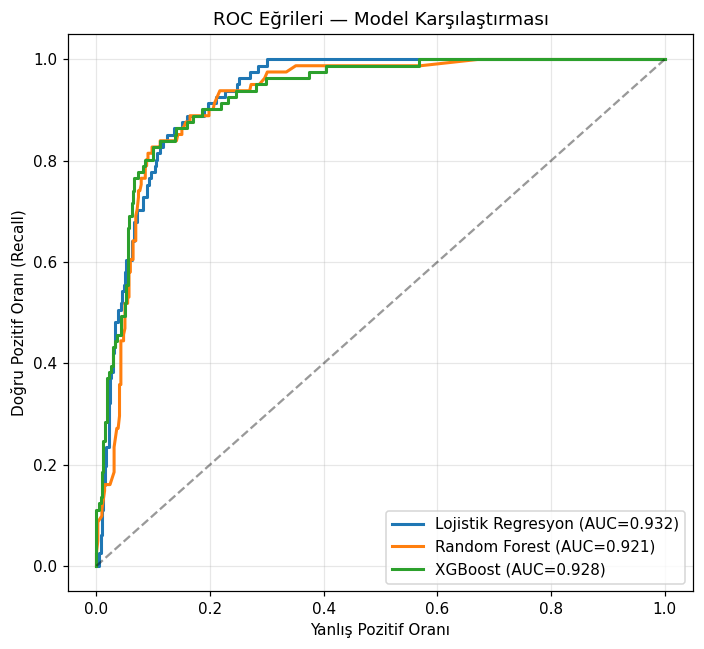

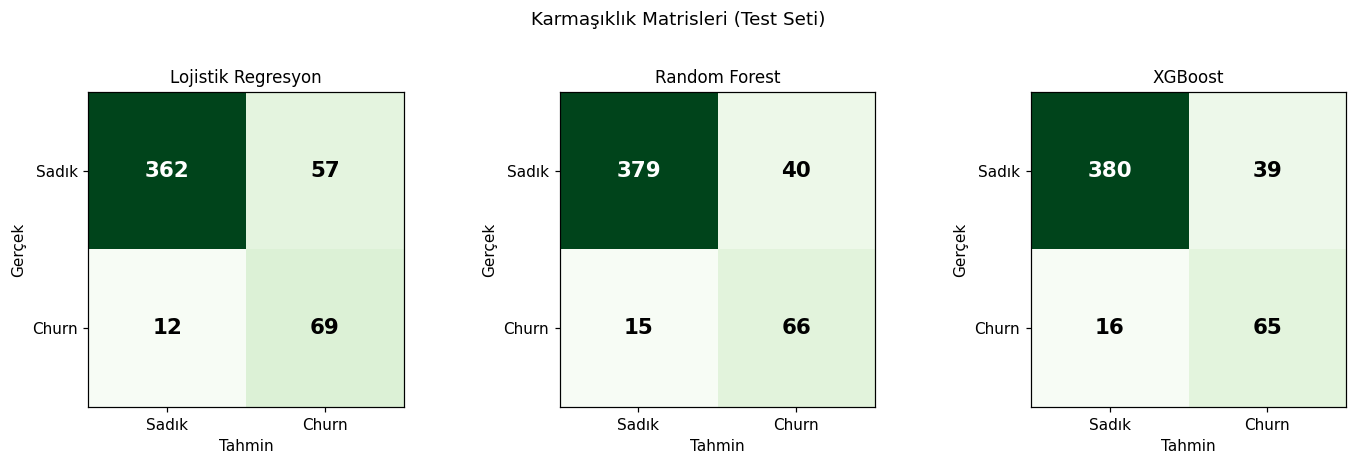


ADIM 4 TAMAM. Grafikler: 05_roc_egrileri, 06_karmasiklik_matrisleri


In [ ]:
"""
============================================================================
ADIM 4 — MODELLEME / Churn Modelleme (A Kolu)
============================================================================
Üç model, AYNI koşulda (SMOTE-ENN ile dengelenmiş train, dokunulmamış test):
  1) Lojistik Regresyon  (baseline, yorumlanabilir)   + StandardScaler
  2) Random Forest        (bagging; Imani 2025)
  3) XGBoost              (boosting; "altın standart", Imani 2025)

Tasarım kararları:
  - imblearn Pipeline kullanılır: SMOTE-ENN SADECE eğitim katlamasına uygulanır,
    test'e asla sızmaz (sıra ve sızıntı garanti).
  - Scaling yalnızca LR'a (ölçeğe duyarlı). Ağaçlar ölçeğe duyarsız.
  - XGBoost'a ayrıca scale_pos_weight VERİLMEZ (SMOTE-ENN zaten dengeledi;
    çifte dengeleme olmasın).
Metrikler: Precision, Recall, F1, F2, AUC-ROC (Accuracy DEĞİL).
============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             fbeta_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RS = 42
CIKTI_G = "/content/grafikler"
CIKTI_S = "/content/sonuclar"
os.makedirs(CIKTI_G, exist_ok=True); os.makedirs(CIKTI_S, exist_ok=True)

X_train = pd.read_parquet("/content/X_train.parquet")
y_train = pd.read_parquet("/content/y_train.parquet")["churn"]
X_test  = pd.read_parquet("/content/X_test.parquet")
y_test  = pd.read_parquet("/content/y_test.parquet")["churn"]


def pipeline_kur(model, scale=False):
    """SMOTE-ENN (yalnız train) + opsiyonel scaling içeren güvenli pipeline."""
    adimlar = []
    if scale:
        adimlar.append(("scaler", StandardScaler()))
    adimlar.append(("smoteenn", SMOTEENN(random_state=RS)))
    adimlar.append(("clf", model))
    return ImbPipeline(adimlar)


modeller = {
    "Lojistik Regresyon": (LogisticRegression(max_iter=1000, random_state=RS), True),
    "Random Forest":      (RandomForestClassifier(n_estimators=300, random_state=RS,
                                                  n_jobs=-1), False),
    "XGBoost":            (XGBClassifier(n_estimators=300, random_state=RS,
                                         eval_metric="logloss"), False),
}

sonuclar = []
egitilmis = {}   # ROC için sakla
for ad, (model, scale) in modeller.items():
    pipe = pipeline_kur(model, scale=scale)
    pipe.fit(X_train, y_train)
    tah  = pipe.predict(X_test)
    olas = pipe.predict_proba(X_test)[:, 1]
    egitilmis[ad] = (pipe, olas, tah)
    sonuclar.append({
        "Model": ad,
        "Precision": precision_score(y_test, tah),
        "Recall":    recall_score(y_test, tah),
        "F1":        f1_score(y_test, tah),
        "F2":        fbeta_score(y_test, tah, beta=2),
        "AUC":       roc_auc_score(y_test, olas),
    })

df = pd.DataFrame(sonuclar)
print("="*78)
print("MODEL KARŞILAŞTIRMASI (SMOTE-ENN, dokunulmamış test)")
print("="*78)
print(df.round(4).to_string(index=False))
df.round(4).to_csv(f"{CIKTI_S}/adim4_model_karsilastirma.csv", index=False)
print(f"\nKaydedildi: {CIKTI_S}/adim4_model_karsilastirma.csv")

# --- ROC eğrileri ---
fig, ax = plt.subplots(figsize=(6.5, 6))
for ad, (_, olas, _) in egitilmis.items():
    fpr, tpr, _ = roc_curve(y_test, olas)
    auc = roc_auc_score(y_test, olas)
    ax.plot(fpr, tpr, linewidth=2, label=f"{ad} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("Yanlış Pozitif Oranı"); ax.set_ylabel("Doğru Pozitif Oranı (Recall)")
ax.set_title("ROC Eğrileri — Model Karşılaştırması"); ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{CIKTI_G}/05_roc_egrileri.png"); plt.show()

# --- Confusion matrix (3 model yan yana) ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (ad, (_, _, tah)) in zip(axes, egitilmis.items()):
    cm = confusion_matrix(y_test, tah)
    im = ax.imshow(cm, cmap="Greens")
    ax.set_title(ad, fontsize=11)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Sadık", "Churn"]); ax.set_yticklabels(["Sadık", "Churn"])
    ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=14, fontweight="bold")
plt.suptitle("Karmaşıklık Matrisleri (Test Seti)", y=1.03)
plt.tight_layout(); plt.savefig(f"{CIKTI_G}/06_karmasiklik_matrisleri.png",
                                bbox_inches="tight"); plt.show()

print("\nADIM 4 TAMAM. Grafikler: 05_roc_egrileri, 06_karmasiklik_matrisleri")

Çıkarıldı (yumuşak sızıntı): musteri_omru_gun
Kalan özellik sayısı: 25

NİHAİ MODEL — XGBoost + SMOTE-ENN (sızıntı temizlenmiş, test seti)
              precision    recall  f1-score   support

       Sadık      0.938     0.909     0.924       419
       Churn      0.596     0.691     0.640        81

    accuracy                          0.874       500
   macro avg      0.767     0.800     0.782       500
weighted avg      0.883     0.874     0.878       500

                      Model  Precision  Recall   F1     F2    AUC
XGBoost + SMOTE-ENN (nihai)     0.5957  0.6914 0.64 0.6699 0.8928


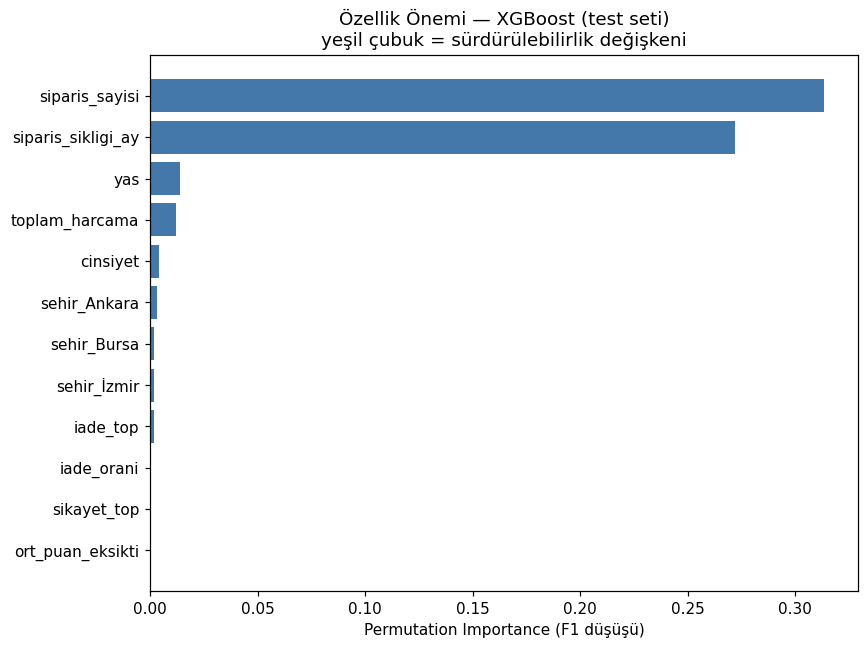


--- En önemli 8 değişken ---
  siparis_sayisi         0.3135
  siparis_sikligi_ay     0.2719
  yas                    0.0137
  toplam_harcama         0.0120
  cinsiyet               0.0044
  sehir_Ankara           0.0031
  sehir_Bursa            0.0020
  sehir_İzmir            0.0018

--- Sürdürülebilirlik değişkenlerinin sırası ---
  ort_yesil_oran         -> 22. sırada (önem=-0.0111)
  toplam_yesil_urun      -> 17. sırada (önem=-0.0007)

ADIM 5 TAMAM. Çıktılar: 07_feature_importance.png, adim5_nihai_metrikler.csv, adim5_feature_importance.csv


In [ ]:
"""
============================================================================
ADIM 5 — DEĞERLENDİRME ve YORUMLAMA / Churn Modelleme (A Kolu)
============================================================================
İçerik:
  (0) YUMUŞAK SIZINTI TEMİZLİĞİ: musteri_omru_gun çıkarılır.
      Gerekçe: bu değişken recency_gun ile -0.72 korelasyonludur (sabit veri
      penceresinde churn edenin "ömrü" yapısal olarak kısa kesilir). recency'yi
      arka kapıdan sızdırdığı için, "davranıştan churn tahmini" amacına uymaz.
      Çıkarınca model siparis_sayisi / siparis_sikligi_ay gibi DAVRANIŞSAL
      değişkenlere dayanır (metodolojik hedefe uygun).
  (1) Nihai model: XGBoost + SMOTE-ENN.
  (2) Feature importance: permutation (test seti, güvenilir) + XGBoost gain.
  (3) classification_report + nihai metrik özeti.

Not: Sızıntı temizliği yalnızca bu adımda gösterim amaçlı yapılıyor. İstersen
     Adim1'deki 'cikar' listesine 'musteri_omru_gun' eklenip baştan da
     uygulanabilir; sonuç aynıdır.
============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (classification_report, precision_score,
                             recall_score, f1_score, fbeta_score, roc_auc_score)
from sklearn.inspection import permutation_importance
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RS = 42
CIKTI_G = "/content/grafikler"; CIKTI_S = "/content/sonuclar"
os.makedirs(CIKTI_G, exist_ok=True); os.makedirs(CIKTI_S, exist_ok=True)

X_train = pd.read_parquet("/content/X_train.parquet")
y_train = pd.read_parquet("/content/y_train.parquet")["churn"]
X_test  = pd.read_parquet("/content/X_test.parquet")
y_test  = pd.read_parquet("/content/y_test.parquet")["churn"]

# --- (0) Yumuşak sızıntı temizliği ---
SIZAN = "musteri_omru_gun"
X_train = X_train.drop(columns=[SIZAN])
X_test  = X_test.drop(columns=[SIZAN])
print(f"Çıkarıldı (yumuşak sızıntı): {SIZAN}")
print(f"Kalan özellik sayısı: {X_train.shape[1]}\n")

# --- (1) Nihai model: XGBoost + SMOTE-ENN ---
pipe = ImbPipeline([
    ("smoteenn", SMOTEENN(random_state=RS)),
    ("clf", XGBClassifier(n_estimators=300, random_state=RS, eval_metric="logloss")),
])
pipe.fit(X_train, y_train)
tah  = pipe.predict(X_test)
olas = pipe.predict_proba(X_test)[:, 1]

print("="*64)
print("NİHAİ MODEL — XGBoost + SMOTE-ENN (sızıntı temizlenmiş, test seti)")
print("="*64)
print(classification_report(y_test, tah, target_names=["Sadık", "Churn"], digits=3))

ozet = pd.DataFrame([{
    "Model": "XGBoost + SMOTE-ENN (nihai)",
    "Precision": precision_score(y_test, tah),
    "Recall":    recall_score(y_test, tah),
    "F1":        f1_score(y_test, tah),
    "F2":        fbeta_score(y_test, tah, beta=2),
    "AUC":       roc_auc_score(y_test, olas),
}])
print(ozet.round(4).to_string(index=False))
ozet.round(4).to_csv(f"{CIKTI_S}/adim5_nihai_metrikler.csv", index=False)

# --- (2) Permutation importance (test seti, F1) ---
perm = permutation_importance(pipe, X_test, y_test, n_repeats=20,
                              random_state=RS, scoring="f1")
pi = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
pi.to_frame("permutation_importance").to_csv(
    f"{CIKTI_S}/adim5_feature_importance.csv")

top = pi.tail(12)   # en önemli 12
fig, ax = plt.subplots(figsize=(8, 6))
renkler = ["#3a7d44" if ("yesil" in k) else "#4477aa" for k in top.index]
ax.barh(top.index, top.values, color=renkler)
ax.set_xlabel("Permutation Importance (F1 düşüşü)")
ax.set_title("Özellik Önemi — XGBoost (test seti)\nyeşil çubuk = sürdürülebilirlik değişkeni")
plt.tight_layout()
plt.savefig(f"{CIKTI_G}/07_feature_importance.png", bbox_inches="tight"); plt.show()

print("\n--- En önemli 8 değişken ---")
for k, v in pi.tail(8)[::-1].items():
    isaret = "  <-- YEŞİL" if "yesil" in k else ""
    print(f"  {k:22} {v:.4f}{isaret}")

# yeşillik değişkenleri nerede?
yesil_kols = [c for c in X_test.columns if "yesil" in c]
print("\n--- Sürdürülebilirlik değişkenlerinin sırası ---")
sirali = pi.sort_values(ascending=False).reset_index()
for yk in yesil_kols:
    rank = sirali[sirali["index"] == yk].index[0] + 1
    print(f"  {yk:22} -> {rank}. sırada (önem={pi[yk]:.4f})")

print("\nADIM 5 TAMAM. Çıktılar: 07_feature_importance.png, "
      "adim5_nihai_metrikler.csv, adim5_feature_importance.csv")

In [ ]:
# === TÜM ÇIKTILARI TEK ZIP OLARAK İNDİR (en altta, en son çalıştır) ===
import shutil, os
from google.colab import files

# eski birikintileri temizle (temiz zip için)
for yol in ["/content/ciktilar", "/content/ciktilar.zip"]:
    if os.path.exists(yol):
        shutil.rmtree(yol) if os.path.isdir(yol) else os.remove(yol)

os.makedirs("/content/ciktilar/grafikler", exist_ok=True)
os.makedirs("/content/ciktilar/sonuclar", exist_ok=True)

# grafikleri ve sonuçları kopyala
for f in os.listdir("/content/grafikler"):
    shutil.copy(f"/content/grafikler/{f}", f"/content/ciktilar/grafikler/{f}")
for f in os.listdir("/content/sonuclar"):
    shutil.copy(f"/content/sonuclar/{f}", f"/content/ciktilar/sonuclar/{f}")

# zip'le
shutil.make_archive("/content/ciktilar", "zip", "/content/ciktilar")

# ekrana içeriği bas (neyin indiğini gör)
print("Zip içeriği:")
for kok, _, dosyalar in os.walk("/content/ciktilar"):
    for d in sorted(dosyalar):
        print("  ", os.path.join(kok, d).replace("/content/ciktilar/", ""))

# indir
files.download("/content/ciktilar.zip")
print("\nciktilar.zip indiriliyor.")

Zip içeriği:
   sonuclar/adim3_dengeleme_karsilastirma.csv
   sonuclar/adim4_model_karsilastirma.csv
   sonuclar/adim5_feature_importance.csv
   sonuclar/adim5_nihai_metrikler.csv
   grafikler/01_yesil_vs_churn.png
   grafikler/02_segment_churn.png
   grafikler/03_mevsimsellik.png
   grafikler/04_dengeleme_karsilastirma.png
   grafikler/05_roc_egrileri.png
   grafikler/06_karmasiklik_matrisleri.png
   grafikler/07_feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ciktilar.zip indiriliyor.
